In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_CLASSES = 14

NUM_WORKERS = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Cell 3 : Check Uploaded Model
# ============================================================

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for f in files:

        print("   ", f)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/arconn
/kaggle/input/models/swastikprakash/arconn/pytorch
/kaggle/input/models/swastikprakash/arconn/pytorch/default
/kaggle/input/models/swastikprakash/arconn/pytorch/default/1
    best_arcface_model.pth


In [4]:
# ============================================================
# Cell 4 : Disease Labels
# ============================================================

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"

]

In [5]:
# ============================================================
# Cell 5 : Load Metadata
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

metadata = pd.read_csv(

    os.path.join(

        DATASET_PATH,

        "Data_Entry_2017.csv"

    )

)

metadata = metadata.drop(

    columns=["Unnamed: 11"],

    errors="ignore"

)

print(metadata.shape)

(112120, 11)


In [6]:
# ============================================================
# Cell 6 : Create Image Path Dictionary
# ============================================================

IMAGE_PATH_DICT = {}

image_files = glob(
    os.path.join(
        DATASET_PATH,
        "images_*",
        "images",
        "*.png"
    )
)

for img in image_files:

    IMAGE_PATH_DICT[
        os.path.basename(img)
    ] = img

metadata["Image Path"] = metadata["Image Index"].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print("="*60)
print("Images Found :", len(metadata))
print("="*60)

Images Found : 112120


In [7]:
# ============================================================
# Cell 7 : Multi-label Encoding
# ============================================================

for disease in DISEASES:

    metadata[disease] = metadata["Finding Labels"].apply(

        lambda x: int(
            disease in x.split("|")
        )

    )

print(metadata[DISEASES].head())

   Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  \
0            0             1              0      0         0          0   
1            0             1              0      0         0          1   
2            0             1              0      0         1          0   
3            0             0              0      0         0          0   
4            0             0              0      0         0          0   

   Fibrosis  Hernia  Infiltration  Mass  Nodule  Pleural_Thickening  \
0         0       0             0     0       0                   0   
1         0       0             0     0       0                   0   
2         0       0             0     0       0                   0   
3         0       0             0     0       0                   0   
4         0       1             0     0       0                   0   

   Pneumonia  Pneumothorax  
0          0             0  
1          0             0  
2          0             0  
3     

In [8]:
# ============================================================
# Cell 8 : Patient-wise Split
# ============================================================

gss1 = GroupShuffleSplit(

    n_splits=1,

    train_size=0.70,

    random_state=42

)

train_idx, temp_idx = next(

    gss1.split(

        metadata,

        groups=metadata["Patient ID"]

    )

)

train_df = metadata.iloc[train_idx].reset_index(drop=True)

temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(

    n_splits=1,

    train_size=2/3,

    random_state=42

)

val_idx, test_idx = next(

    gss2.split(

        temp_df,

        groups=temp_df["Patient ID"]

    )

)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("="*60)

print("Train      :", len(train_df))

print("Validation :", len(val_df))

print("Test       :", len(test_df))

print("="*60)

Train      : 78566
Validation : 22204
Test       : 11350


In [9]:
# ============================================================
# Cell 9 : CLAHE
# ============================================================

def apply_clahe(image):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(image)

In [10]:
# ============================================================
# Cell 10 : Transform
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [11]:
# ============================================================
# Cell 11 : Dataset
# ============================================================

class PrototypeDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(

            row["Image Path"],

            cv2.IMREAD_GRAYSCALE

        )

        image = apply_clahe(image)

        image = cv2.cvtColor(

            image,

            cv2.COLOR_GRAY2RGB

        )

        image = transform(image)

        label = row[
            DISEASES
        ].values.astype(np.float32)

        return image, torch.tensor(label)

In [12]:
# ============================================================
# Cell 12 : DataLoaders
# ============================================================

train_dataset = PrototypeDataset(train_df)

val_dataset = PrototypeDataset(val_df)

test_dataset = PrototypeDataset(test_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

print("="*60)

print("Train :", len(train_dataset))

print("Validation :", len(val_dataset))

print("Test :", len(test_dataset))

print("="*60)

Train : 78566
Validation : 22204
Test : 11350


In [13]:
# ============================================================
# Cell 13 : Check Uploaded ArcFace Model
# ============================================================

print("="*80)

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for file in files:

        print("   ", file)

print("="*80)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/arconn
/kaggle/input/models/swastikprakash/arconn/pytorch
/kaggle/input/models/swastikprakash/arconn/pytorch/default
/kaggle/input/models/swastikprakash/arconn/pytorch/default/1
    best_arcface_model.pth


In [14]:
# ============================================================
# Cell 14 : Build ArcFace Network
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

backbone = convnext_tiny(weights=weights)

in_features = backbone.classifier[2].in_features

backbone.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

backbone = backbone.to(DEVICE)

print("="*60)
print(backbone.classifier)
print("="*60)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 180MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [15]:
# ============================================================
# Cell 15 : ArcFace Layer
# ============================================================

class ArcMarginProduct(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 s=30.0,
                 m=0.50):

        super().__init__()

        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(self.weight)

    def forward(self, features):

        features = F.normalize(features)

        weight = F.normalize(self.weight)

        cosine = F.linear(features, weight)

        cosine = torch.clamp(
            cosine,
            -1 + 1e-7,
            1 - 1e-7
        )

        theta = torch.acos(cosine)

        logits = torch.cos(theta + self.m)

        logits *= self.s

        return logits

In [16]:
# ============================================================
# Cell 16 : Feature Extractor
# ============================================================

class ConvNeXtFeatureExtractor(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.features = backbone.features

        self.avgpool = backbone.avgpool

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        return x

In [17]:
# ============================================================
# Cell 17 : ArcFace Model
# ============================================================

class ArcFaceModel(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.encoder = ConvNeXtFeatureExtractor(backbone)

        self.arcface = ArcMarginProduct(

            768,

            NUM_CLASSES

        )

    def forward(self, x):

        embedding = self.encoder(x)

        logits = self.arcface(embedding)

        return embedding, logits


arcface_model = ArcFaceModel(backbone).to(DEVICE)

print(arcface_model)

ArcFaceModel(
  (encoder): ConvNeXtFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2)

In [18]:
# ============================================================
# Cell 18 : Load ArcFace Model
# ============================================================

MODEL_PATH = "/kaggle/input/models/swastikprakash/arconn/pytorch/default/1/best_arcface_model.pth"

checkpoint = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=False

)

arcface_model.load_state_dict(

    checkpoint["model_state_dict"]

)

arcface_model.eval()

print("="*60)

print("ArcFace Model Loaded Successfully")

print("="*60)

ArcFace Model Loaded Successfully


In [19]:
# ============================================================
# Cell 19 : Keep Only Encoder
# ============================================================

encoder = arcface_model.encoder

encoder.eval()

print("="*60)

print("Encoder Extracted")

print(encoder)

print("="*60)

Encoder Extracted
ConvNeXtFeatureExtractor(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)


In [20]:
# ============================================================
# Cell 20 : Verify Embeddings
# ============================================================

dummy = torch.randn(

    4,

    3,

    224,

    224

).to(DEVICE)

with torch.no_grad():

    embedding = encoder(dummy)

print("="*60)

print("Embedding Shape :", embedding.shape)

print("="*60)

Embedding Shape : torch.Size([4, 768])


In [21]:
# ============================================================
# Cell 21 : Extract Training Embeddings
# ============================================================

train_embeddings = []

train_labels = []

encoder.eval()

with torch.no_grad():

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)

        embeddings = encoder(images)

        train_embeddings.append(

            embeddings.cpu()

        )

        train_labels.append(

            labels

        )

train_embeddings = torch.cat(

    train_embeddings,

    dim=0

)

train_labels = torch.cat(

    train_labels,

    dim=0

)

print("="*60)

print("Embeddings :", train_embeddings.shape)

print("Labels :", train_labels.shape)

print("="*60)

  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Embeddings : torch.Size([78566, 768])
Labels : torch.Size([78566, 14])


In [22]:
# ============================================================
# Cell 22 : Save Embeddings
# ============================================================

torch.save(

    train_embeddings,

    "/kaggle/working/train_embeddings.pt"

)

torch.save(

    train_labels,

    "/kaggle/working/train_labels.pt"

)

print("="*60)

print("Training Embeddings Saved")

print("="*60)

Training Embeddings Saved


In [23]:
# ============================================================
# Cell 22A : Remove Outliers Before Prototype Construction
# ============================================================

from sklearn.ensemble import IsolationForest
import numpy as np
import torch

print("=" * 70)
print("Removing Outliers using Isolation Forest")
print("=" * 70)

filtered_embeddings = {}
filtered_counts = {}

for idx, disease in enumerate(DISEASES):

    # Multi-label selection
    mask = train_labels[:, idx] == 1

    disease_embeddings = train_embeddings[mask]

    if len(disease_embeddings) < 20:

        filtered_embeddings[disease] = disease_embeddings
        filtered_counts[disease] = len(disease_embeddings)

        print(f"{disease:22s} : "
              f"{len(disease_embeddings):5d} samples "
              f"(Skipped Outlier Removal)")

        continue

    iso = IsolationForest(

        contamination=0.05,
        random_state=42

    )

    prediction = iso.fit_predict(

        disease_embeddings.numpy()

    )

    keep = prediction == 1

    cleaned = disease_embeddings[keep]

    filtered_embeddings[disease] = cleaned

    filtered_counts[disease] = len(cleaned)

    removed = len(disease_embeddings) - len(cleaned)

    print(f"{disease:22s} : "
          f"{len(cleaned):5d} kept | "
          f"{removed:4d} removed")

print("=" * 70)
print("Outlier Removal Completed")
print("=" * 70)

Removing Outliers using Isolation Forest
Atelectasis            :  7780 kept |  410 removed
Cardiomegaly           :  1796 kept |   95 removed
Consolidation          :  3066 kept |  162 removed
Edema                  :  1548 kept |   82 removed
Effusion               :  8966 kept |  472 removed
Emphysema              :  1582 kept |   84 removed
Fibrosis               :  1098 kept |   58 removed
Hernia                 :   150 kept |    8 removed
Infiltration           : 13174 kept |  694 removed
Mass                   :  4047 kept |  213 removed
Nodule                 :  4210 kept |  222 removed
Pleural_Thickening     :  2260 kept |  119 removed
Pneumonia              :   945 kept |   50 removed
Pneumothorax           :  3581 kept |  189 removed
Outlier Removal Completed


In [24]:
# ============================================================
# Cell 23 : Multi-Prototype Memory Construction
# ============================================================

from sklearn.cluster import KMeans
import torch.nn.functional as F

NUM_PROTOTYPES = 3

prototype_memory = {}

prototype_weights = {}

print("=" * 70)
print("Building Multi-Prototype Memory")
print("=" * 70)

for idx, disease in enumerate(DISEASES):

    embeddings = filtered_embeddings[disease]

    embeddings = F.normalize(
        embeddings,
        dim=1
    )

    n_samples = len(embeddings)

    if n_samples <= NUM_PROTOTYPES:

        prototypes = embeddings.clone()

        weights = torch.ones(
            len(prototypes)
        ) / len(prototypes)

    else:

        kmeans = KMeans(

            n_clusters=NUM_PROTOTYPES,

            random_state=42,

            n_init="auto"

        )

        cluster_ids = kmeans.fit_predict(

            embeddings.numpy()

        )

        prototypes = []

        weights = []

        for cluster in range(NUM_PROTOTYPES):

            cluster_embeddings = embeddings[
                cluster_ids == cluster
            ]

            prototype = cluster_embeddings.mean(dim=0)

            prototype = F.normalize(

                prototype.unsqueeze(0),

                dim=1

            ).squeeze(0)

            prototypes.append(prototype)

            weights.append(

                len(cluster_embeddings)

            )

        prototypes = torch.stack(

            prototypes

        )

        weights = torch.tensor(

            weights,

            dtype=torch.float32

        )

        weights = weights / weights.sum()

    prototype_memory[disease] = prototypes

    prototype_weights[disease] = weights

    print(f"{disease:22s} : "
          f"{len(prototypes)} prototypes")

print("=" * 70)
print("Prototype Memory Created")
print("=" * 70)

Building Multi-Prototype Memory
Atelectasis            : 3 prototypes
Cardiomegaly           : 3 prototypes
Consolidation          : 3 prototypes
Edema                  : 3 prototypes
Effusion               : 3 prototypes
Emphysema              : 3 prototypes
Fibrosis               : 3 prototypes
Hernia                 : 3 prototypes
Infiltration           : 3 prototypes
Mass                   : 3 prototypes
Nodule                 : 3 prototypes
Pleural_Thickening     : 3 prototypes
Pneumonia              : 3 prototypes
Pneumothorax           : 3 prototypes
Prototype Memory Created


In [25]:
# ============================================================
# Cell 23A : Dynamic Prototype Memory Update (EMA)
# ============================================================

import torch.nn.functional as F

EMA_ALPHA = 0.90

def update_prototype_memory(
    prototype_memory,
    filtered_embeddings,
    prototype_weights
):

    updated_memory = {}

    for disease in DISEASES:

        old_prototypes = prototype_memory[disease]

        new_embeddings = F.normalize(
            filtered_embeddings[disease],
            dim=1
        )

        updated = []

        for i in range(len(old_prototypes)):

            similarity = torch.matmul(
                new_embeddings,
                old_prototypes[i]
            )

            nearest = new_embeddings[
                torch.argmax(similarity)
            ]

            prototype = (

                EMA_ALPHA * old_prototypes[i]

                +

                (1 - EMA_ALPHA) * nearest

            )

            prototype = F.normalize(

                prototype.unsqueeze(0),

                dim=1

            ).squeeze(0)

            updated.append(prototype)

        updated_memory[disease] = torch.stack(updated)

    return updated_memory


prototype_memory = update_prototype_memory(

    prototype_memory,

    filtered_embeddings,

    prototype_weights

)

print("=" * 70)
print("Dynamic Prototype Memory Updated (EMA)")
print("=" * 70)

Dynamic Prototype Memory Updated (EMA)


In [26]:
# ============================================================
# Cell 24 : Verify Prototype Memory
# ============================================================

print("=" * 70)
print("Prototype Memory Summary")
print("=" * 70)

total_prototypes = 0

for disease in DISEASES:

    prototypes = prototype_memory[disease]
    weights = prototype_weights[disease]

    print(f"{disease:22s}")

    print(f"   Number of Prototypes : {len(prototypes)}")

    print(f"   Prototype Shape      : {tuple(prototypes.shape)}")

    print(f"   Cluster Weights      : {weights.numpy()}")

    total_prototypes += len(prototypes)

print("=" * 70)

print(f"Total Diseases   : {len(DISEASES)}")

print(f"Total Prototypes : {total_prototypes}")

print("=" * 70)

Prototype Memory Summary
Atelectasis           
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.34768638 0.30989718 0.34241647]
Cardiomegaly          
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.3207127  0.34688196 0.33240536]
Consolidation         
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.26647097 0.40443575 0.32909328]
Edema                 
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.33139536 0.39470285 0.27390182]
Effusion              
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.41813517 0.26600492 0.3158599 ]
Emphysema             
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Cluster Weights      : [0.38369152 0.43615675 0.1801517 ]
Fibrosis              
   Number of Prototypes : 3
   Prototype Shape      : (3, 768)
   Clus

In [27]:
# ============================================================
# Cell 26 : Multi-Prototype Similarity Function
# ============================================================

import torch
import torch.nn.functional as F

def compute_similarity(query_embedding,
                       prototype_memory,
                       prototype_weights):

    # Normalize query embedding
    query_embedding = F.normalize(
        query_embedding,
        dim=0
    )

    similarity_scores = {}

    for disease in DISEASES:

        prototypes = prototype_memory[disease]

        weights = prototype_weights[disease]

        # Cosine similarity with every prototype
        similarities = torch.matmul(
            prototypes,
            query_embedding
        )

        # Weighted similarities
        weighted_similarities = similarities * weights

        # Best prototype represents disease
        similarity_scores[disease] = {

            "max_similarity": weighted_similarities.max().item(),

            "best_prototype": weighted_similarities.argmax().item(),

            "all_similarities": weighted_similarities.cpu()

        }

    return similarity_scores


print("=" * 70)
print("Multi-Prototype Similarity Function Ready")
print("=" * 70)

Multi-Prototype Similarity Function Ready


In [28]:
# ============================================================
# Cell 27 : Validation Embeddings
# ============================================================

val_embeddings = []

val_labels = []

encoder.eval()

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(DEVICE)

        embeddings = encoder(images)

        val_embeddings.append(

            embeddings.cpu()

        )

        val_labels.append(

            labels

        )

val_embeddings = torch.cat(

    val_embeddings

)

val_labels = torch.cat(

    val_labels

)

print(val_embeddings.shape)

print(val_labels.shape)

  0%|          | 0/694 [00:00<?, ?it/s]

torch.Size([22204, 768])
torch.Size([22204, 14])


In [29]:
# ============================================================
# Cell 28 : Multi-Prototype Similarity Matrix
# ============================================================

import torch.nn.functional as F

val_embeddings = F.normalize(
    val_embeddings,
    dim=1
)

similarity_scores = []

best_prototype_index = []

for embedding in tqdm(val_embeddings):

    disease_scores = []

    disease_best = []

    scores = compute_similarity(

        embedding,

        prototype_memory,

        prototype_weights

    )

    for disease in DISEASES:

        disease_scores.append(

            scores[disease]["max_similarity"]

        )

        disease_best.append(

            scores[disease]["best_prototype"]

        )

    similarity_scores.append(

        disease_scores

    )

    best_prototype_index.append(

        disease_best

    )

similarity_scores = torch.tensor(

    similarity_scores

)

best_prototype_index = torch.tensor(

    best_prototype_index

)

print("="*70)

print("Similarity Matrix :", similarity_scores.shape)

print("Prototype Index Matrix :", best_prototype_index.shape)

print("="*70)

  0%|          | 0/22204 [00:00<?, ?it/s]

Similarity Matrix : torch.Size([22204, 14])
Prototype Index Matrix : torch.Size([22204, 14])


In [30]:
# ============================================================
# Cell 29 : Best Disease Prediction
# ============================================================

predicted_indices = torch.argmax(
    similarity_scores,
    dim=1
)

predicted_diseases = [

    DISEASES[idx]

    for idx in predicted_indices

]

prediction_confidence = torch.max(

    similarity_scores,

    dim=1

).values

print("=" * 70)

print("Predictions Ready")

print(f"Total Validation Images : {len(predicted_diseases)}")

print("=" * 70)

print("\nFirst Five Predictions\n")

for i in range(5):

    print(

        f"Prediction {i+1:2d} : "

        f"{predicted_diseases[i]:22s}"

        f" Confidence = {prediction_confidence[i]:.4f}"

    )

Predictions Ready
Total Validation Images : 22204

First Five Predictions

Prediction  1 : Effusion               Confidence = 0.2030
Prediction  2 : Cardiomegaly           Confidence = 0.2336
Prediction  3 : Effusion               Confidence = 0.2124
Prediction  4 : Effusion               Confidence = 0.2321
Prediction  5 : Nodule                 Confidence = 0.2801


In [31]:
# ============================================================
# Cell 30 : Learn Adaptive Thresholds for Each Disease
# ============================================================

from sklearn.metrics import f1_score
import numpy as np

adaptive_thresholds = {}

print("=" * 80)
print("Learning Adaptive Threshold for Each Disease")
print("=" * 80)

for disease_idx, disease in enumerate(DISEASES):

    y_true = val_labels[:, disease_idx].numpy().astype(int)

    similarity = similarity_scores[:, disease_idx].numpy()

    # ----------------------------------------------------
    # Search inside ACTUAL similarity range
    # ----------------------------------------------------

    min_sim = similarity.min()

    max_sim = similarity.max()

    threshold_candidates = np.linspace(
        min_sim,
        max_sim,
        100
    )

    best_threshold = min_sim

    best_f1 = -1

    for threshold in threshold_candidates:

        y_pred = (similarity >= threshold).astype(int)

        score = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        if score > best_f1:

            best_f1 = score

            best_threshold = threshold

    adaptive_thresholds[disease] = float(best_threshold)

    print(
        f"{disease:22s}"
        f" | Threshold = {best_threshold:.4f}"
        f" | F1 = {best_f1:.4f}"
    )

print("=" * 80)
print("Adaptive Threshold Learning Completed")
print("=" * 80)

Learning Adaptive Threshold for Each Disease
Atelectasis            | Threshold = 0.2354 | F1 = 0.3332
Cardiomegaly           | Threshold = 0.2436 | F1 = 0.1856
Consolidation          | Threshold = 0.2921 | F1 = 0.2096
Edema                  | Threshold = 0.2888 | F1 = 0.2366
Effusion               | Threshold = 0.2716 | F1 = 0.4307
Emphysema              | Threshold = 0.3371 | F1 = 0.4032
Fibrosis               | Threshold = 0.2425 | F1 = 0.0973
Hernia                 | Threshold = 0.2558 | F1 = 0.4000
Infiltration           | Threshold = 0.2140 | F1 = 0.3779
Mass                   | Threshold = 0.2511 | F1 = 0.2562
Nodule                 | Threshold = 0.2765 | F1 = 0.2222
Pleural_Thickening     | Threshold = 0.2734 | F1 = 0.1929
Pneumonia              | Threshold = 0.2829 | F1 = 0.0907
Pneumothorax           | Threshold = 0.2696 | F1 = 0.3632
Adaptive Threshold Learning Completed


In [32]:
# ============================================================
# Cell 31 : Predict Known Diseases using Adaptive Thresholds
# ============================================================

predictions = torch.zeros_like(val_labels)

prediction_scores = similarity_scores.clone()

for disease_idx, disease in enumerate(DISEASES):

    threshold = adaptive_thresholds[disease]

    predictions[:, disease_idx] = (

        prediction_scores[:, disease_idx] >= threshold

    ).int()

print("=" * 80)

print("Adaptive Threshold Prediction Completed")

print("Prediction Shape :", predictions.shape)

print("=" * 80)

Adaptive Threshold Prediction Completed
Prediction Shape : torch.Size([22204, 14])


In [33]:
# ============================================================
# Cell 32 : Final Multi-Label Predictions
# ============================================================

final_predictions = predictions.clone()

known_mask = final_predictions.sum(dim=1) > 0

unknown_mask = ~known_mask

print("="*80)

print("Prediction Summary")

print("="*80)

print(f"Known Images   : {known_mask.sum().item()}")

print(f"Unknown Images : {unknown_mask.sum().item()}")

print("="*80)

Prediction Summary
Known Images   : 11167
Unknown Images : 11037


In [34]:
# ============================================================
# Cell 33 : Metrics
# ============================================================

from sklearn.metrics import *

accuracy = accuracy_score(

    val_labels.numpy(),

    predictions

)

precision = precision_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

recall = recall_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

f1 = f1_score(

    val_labels.numpy(),

    predictions,

    average="macro",

    zero_division=0

)

auroc = roc_auc_score(

    val_labels.numpy(),

    similarity_scores.numpy(),

    average="macro"

)

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print(f"AUROC     : {auroc:.4f}")

print("="*60)

Accuracy  : 0.3906
Precision : 0.2297
Recall    : 0.3843
F1 Score  : 0.2714
AUROC     : 0.7844


In [35]:
# ============================================================
# Cell 34 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(

classification_report(

    val_labels.numpy(),

    predictions,

    target_names=DISEASES,

    zero_division=0

)

)

                    precision    recall  f1-score   support

       Atelectasis       0.24      0.54      0.33      2204
      Cardiomegaly       0.12      0.40      0.19       556
     Consolidation       0.15      0.32      0.21       979
             Edema       0.17      0.38      0.24       465
          Effusion       0.34      0.58      0.43      2620
         Emphysema       0.37      0.44      0.40       515
          Fibrosis       0.06      0.24      0.10       350
            Hernia       0.54      0.32      0.40        44
      Infiltration       0.27      0.61      0.38      4067
              Mass       0.20      0.35      0.26      1008
            Nodule       0.21      0.23      0.22      1274
Pleural_Thickening       0.14      0.32      0.19       667
         Pneumonia       0.06      0.24      0.09       303
      Pneumothorax       0.33      0.40      0.36       937

         micro avg       0.23      0.47      0.31     15989
         macro avg       0.23      0.3

In [36]:
# ============================================================
# Cell 35 : Multi-label Confusion Matrix
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix

cms = multilabel_confusion_matrix(

    val_labels.numpy(),

    predictions

)

for i,disease in enumerate(DISEASES):

    print("="*50)

    print(disease)

    print(cms[i])

Atelectasis
[[16247  3753]
 [ 1013  1191]]
Cardiomegaly
[[20053  1595]
 [  336   220]]
Consolidation
[[19487  1738]
 [  661   318]]
Edema
[[20885   854]
 [  288   177]]
Effusion
[[16644  2940]
 [ 1094  1526]]
Emphysema
[[21313   376]
 [  290   225]]
Fibrosis
[[20541  1313]
 [  265    85]]
Hernia
[[22148    12]
 [   30    14]]
Infiltration
[[11551  6586]
 [ 1585  2482]]
Mass
[[19788  1408]
 [  653   355]]
Nodule
[[19836  1094]
 [  978   296]]
Pleural_Thickening
[[20181  1356]
 [  451   216]]
Pneumonia
[[20689  1212]
 [  231    72]]
Pneumothorax
[[20505   762]
 [  560   377]]


In [37]:
# ============================================================
# Cell 36 : Save Enhanced Prototype Bank
# ============================================================

prototype_bank = {

    "prototype_memory": prototype_memory,

    "prototype_weights": prototype_weights,

    "adaptive_thresholds": adaptive_thresholds,

    "ema_alpha": EMA_ALPHA,

    "num_prototypes": NUM_PROTOTYPES,

    "diseases": DISEASES

}

torch.save(

    prototype_bank,

    "/kaggle/working/prototype_bank.pth"

)

torch.save(

    predictions,

    "/kaggle/working/validation_predictions.pt"

)

np.save(

    "/kaggle/working/validation_similarity.npy",

    similarity_scores.numpy()

)

print("=" * 70)

print("Enhanced Prototype Bank Saved")

print("Validation Predictions Saved")

print("Similarity Matrix Saved")

print(f"EMA Alpha : {EMA_ALPHA}")

print("=" * 70)

Enhanced Prototype Bank Saved
Validation Predictions Saved
Similarity Matrix Saved
EMA Alpha : 0.9


In [38]:
# ============================================================
# Cell 37 : Multi-Label Failure Analysis
# ============================================================

incorrect = (predictions != val_labels).sum(dim=1)

failure_cases = torch.where(incorrect > 0)[0]

print("=" * 70)

print("Failure Analysis")

print("=" * 70)

print(f"Incorrect Samples : {len(failure_cases)}")

print("=" * 70)

for idx in failure_cases[:10]:

    print("-" * 50)

    print(f"Sample : {idx.item()}")

    true_labels = [

        DISEASES[i]

        for i in range(NUM_CLASSES)

        if val_labels[idx, i] == 1

    ]

    pred_labels = [

        DISEASES[i]

        for i in range(NUM_CLASSES)

        if predictions[idx, i] == 1

    ]

    print("True Diseases :", true_labels)

    print("Pred Diseases :", pred_labels)

    print("Similarity Scores :")

    for i, disease in enumerate(DISEASES):

        print(f"   {disease:22s} : {similarity_scores[idx, i]:.4f}")

Failure Analysis
Incorrect Samples : 13532
--------------------------------------------------
Sample : 1
True Diseases : ['Cardiomegaly']
Pred Diseases : []
Similarity Scores :
   Atelectasis            : 0.1708
   Cardiomegaly           : 0.2336
   Consolidation          : 0.1754
   Edema                  : 0.1289
   Effusion               : 0.2162
   Emphysema              : 0.1759
   Fibrosis               : 0.1820
   Hernia                 : 0.1089
   Infiltration           : 0.1697
   Mass                   : 0.1657
   Nodule                 : 0.1664
   Pleural_Thickening     : 0.2002
   Pneumonia              : 0.1398
   Pneumothorax           : 0.1579
--------------------------------------------------
Sample : 3
True Diseases : ['Nodule']
Pred Diseases : []
Similarity Scores :
   Atelectasis            : 0.2022
   Cardiomegaly           : 0.2062
   Consolidation          : 0.1792
   Edema                  : 0.1274
   Effusion               : 0.2321
   Emphysema              : 0.

In [39]:
# ============================================================
# Cell 38 : Grad-CAM Hooks
# ============================================================

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = arcface_model.encoder.features[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM Hooks Registered")

Grad-CAM Hooks Registered


In [40]:
# ============================================================
# Cell 39 : Generate Grad-CAM
# ============================================================

def generate_gradcam(image_tensor):

    arcface_model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    embedding, logits = arcface_model(image_tensor)

    predicted_class = torch.argmax(logits, dim=1)

    score = logits[:, predicted_class]

    arcface_model.zero_grad()

    score.backward()

    pooled_gradients = gradients.mean(dim=[0,2,3])

    activation = activations.squeeze(0)

    for i in range(len(pooled_gradients)):
        activation[i] *= pooled_gradients[i]

    heatmap = activation.mean(dim=0).cpu().detach().numpy()

    heatmap = np.maximum(heatmap,0)

    heatmap /= (heatmap.max()+1e-8)

    return heatmap, predicted_class.item()

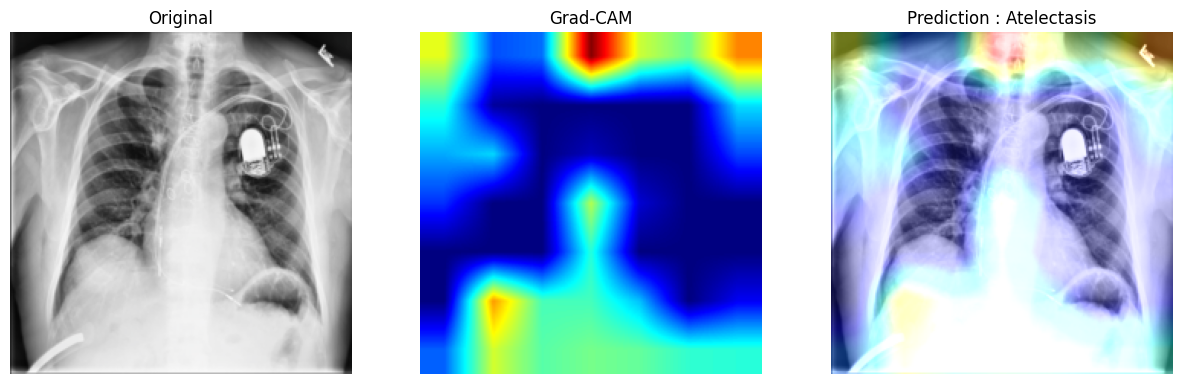

In [41]:
# ============================================================
# Cell 40 : Visualize Grad-CAM
# ============================================================

sample_index = 0

image, label = val_dataset[sample_index]

heatmap, pred = generate_gradcam(image)

image_np = image.permute(1,2,0).numpy()

image_np = image_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

image_np = np.clip(image_np,0,1)

heatmap = cv2.resize(

    heatmap,

    (224,224)

)

heatmap = cv2.applyColorMap(

    np.uint8(255*heatmap),

    cv2.COLORMAP_JET

)

heatmap = cv2.cvtColor(

    heatmap,

    cv2.COLOR_BGR2RGB

)

overlay = 0.4*heatmap/255 + image_np

overlay = np.clip(overlay,0,1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(image_np)

plt.title("Original")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(heatmap)

plt.title("Grad-CAM")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title(f"Prediction : {DISEASES[pred]}")

plt.axis("off")

plt.show()

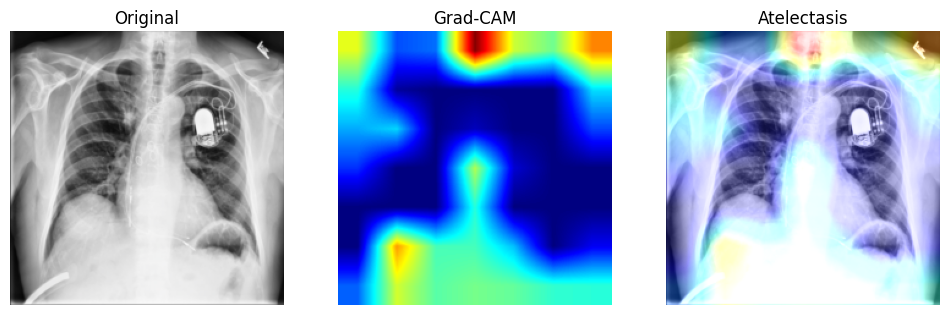

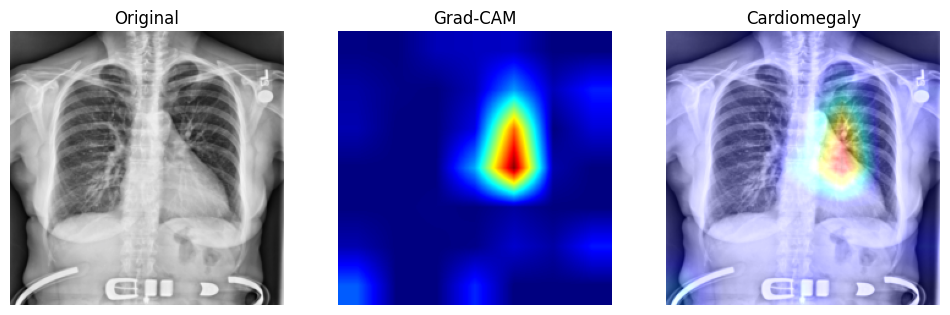

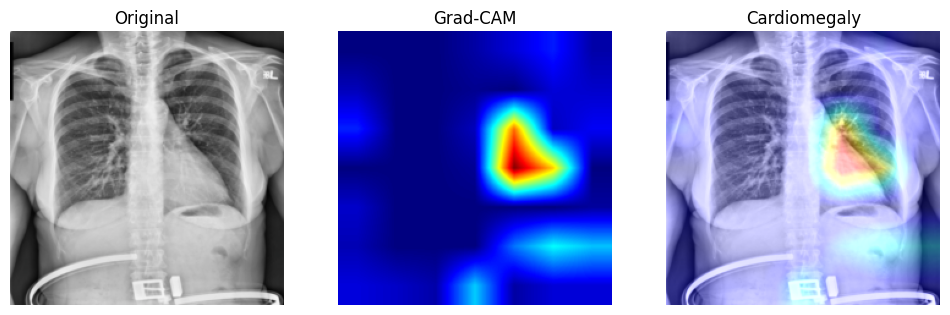

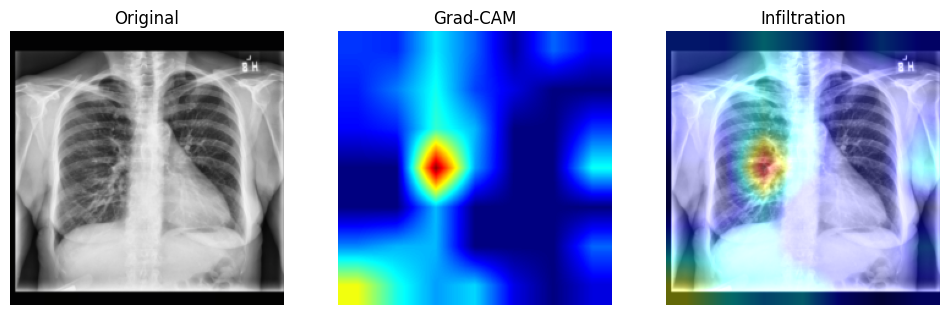

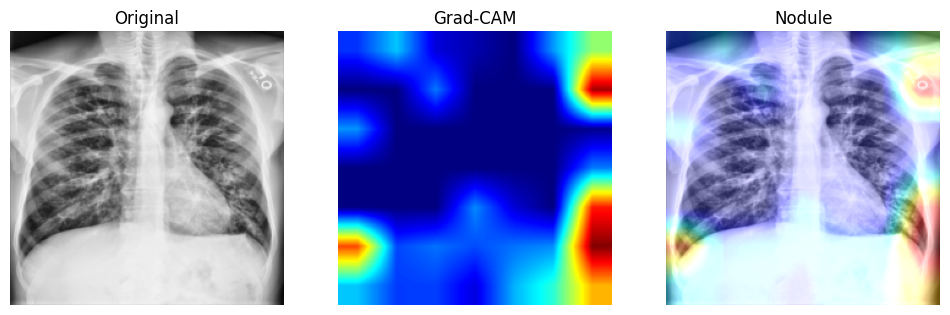

In [42]:
# ============================================================
# Cell 41 : Multiple Grad-CAM Examples
# ============================================================

for idx in range(5):

    image, label = val_dataset[idx]

    heatmap, pred = generate_gradcam(image)

    image_np = image.permute(1,2,0).numpy()

    image_np = image_np * np.array([0.229,0.224,0.225])

    image_np += np.array([0.485,0.456,0.406])

    image_np = np.clip(image_np,0,1)

    heatmap = cv2.resize(

        heatmap,

        (224,224)

    )

    heatmap = cv2.applyColorMap(

        np.uint8(255*heatmap),

        cv2.COLORMAP_JET

    )

    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB

    )

    overlay = 0.4*heatmap/255 + image_np

    overlay = np.clip(overlay,0,1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)

    plt.imshow(image_np)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title(DISEASES[pred])

    plt.axis("off")

    plt.show()

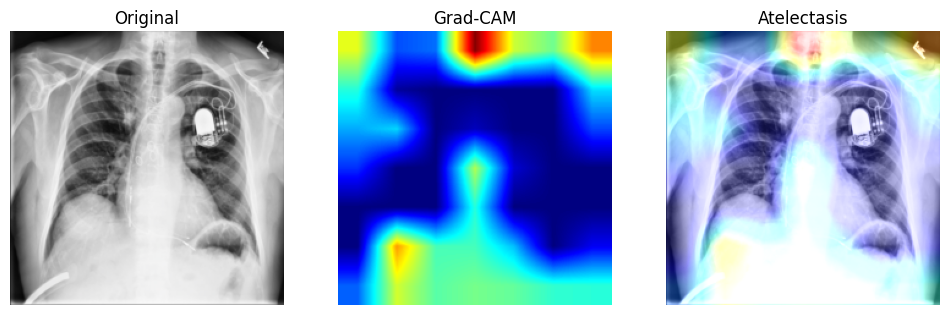

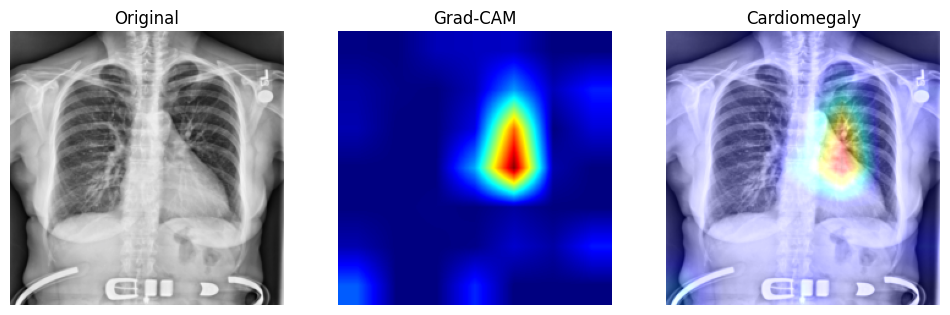

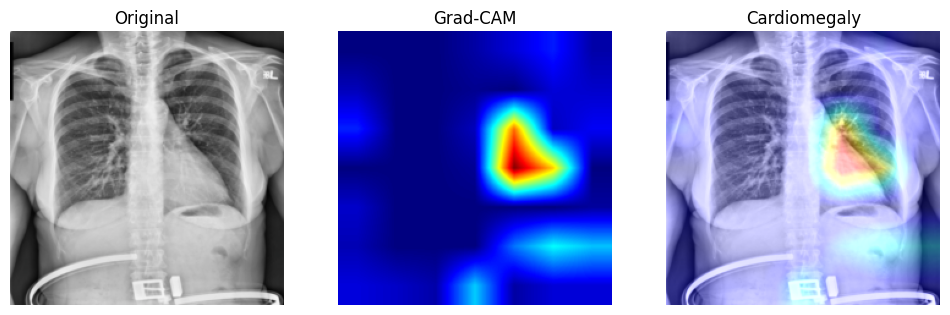

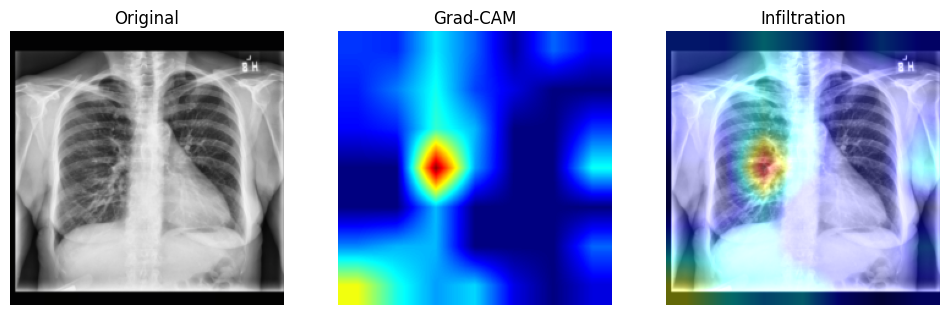

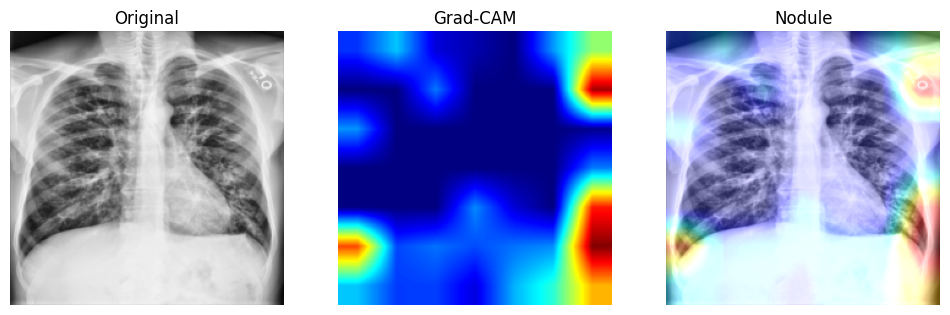

In [43]:
# ============================================================
# Cell 41 : Multiple Grad-CAM Examples
# ============================================================

for idx in range(5):

    image, label = val_dataset[idx]

    heatmap, pred = generate_gradcam(image)

    image_np = image.permute(1,2,0).numpy()

    image_np = image_np * np.array([0.229,0.224,0.225])

    image_np += np.array([0.485,0.456,0.406])

    image_np = np.clip(image_np,0,1)

    heatmap = cv2.resize(

        heatmap,

        (224,224)

    )

    heatmap = cv2.applyColorMap(

        np.uint8(255*heatmap),

        cv2.COLORMAP_JET

    )

    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB

    )

    overlay = 0.4*heatmap/255 + image_np

    overlay = np.clip(overlay,0,1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)

    plt.imshow(image_np)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title(DISEASES[pred])

    plt.axis("off")

    plt.show()

In [44]:
# ============================================================
# Cell 43 : Disease Prototype Similarity Ranking
# ============================================================

import torch
import torch.nn.functional as F

print("=" * 80)
print("Average Disease Prototype Similarity")
print("=" * 80)

pairs = []

for i in range(NUM_CLASSES):

    for j in range(i + 1, NUM_CLASSES):

        proto_i = F.normalize(
            prototype_memory[DISEASES[i]],
            dim=1
        )

        proto_j = F.normalize(
            prototype_memory[DISEASES[j]],
            dim=1
        )

        similarity = torch.mm(
            proto_i,
            proto_j.T
        )

        avg_similarity = similarity.mean().item()

        pairs.append(
            (
                DISEASES[i],
                DISEASES[j],
                avg_similarity
            )
        )

pairs = sorted(
    pairs,
    key=lambda x: x[2],
    reverse=True
)

for disease1, disease2, score in pairs[:10]:

    print(
        f"{disease1:22s} <-> "
        f"{disease2:22s} : "
        f"{score:.4f}"
    )

print("=" * 80)

Average Disease Prototype Similarity
Consolidation          <-> Effusion               : 0.8961
Atelectasis            <-> Effusion               : 0.8800
Consolidation          <-> Pneumonia              : 0.8679
Atelectasis            <-> Consolidation          : 0.8666
Mass                   <-> Nodule                 : 0.8612
Consolidation          <-> Edema                  : 0.8583
Consolidation          <-> Infiltration           : 0.8535
Edema                  <-> Pneumonia              : 0.8524
Fibrosis               <-> Pleural_Thickening     : 0.8511
Effusion               <-> Pneumonia              : 0.8451


In [45]:
# ============================================================
# Cell 44 : Prediction Confidence Statistics
# ============================================================

print("=" * 60)

print("Average Confidence :", prediction_confidence.mean().item())

print("Minimum Confidence :", prediction_confidence.min().item())

print("Maximum Confidence :", prediction_confidence.max().item())

print("Standard Deviation :", prediction_confidence.std().item())

print("=" * 60)

Average Confidence : 0.2610214352607727
Minimum Confidence : 0.10853730142116547
Maximum Confidence : 0.441230833530426
Standard Deviation : 0.042701125144958496


In [46]:
# ============================================================
# Cell 45 : Final Summary
# ============================================================

print("="*80)

print("PHASE COMPLETED")

print("="*80)

print("✓ ArcFace Model Loaded")

print("✓ 768-D Embeddings Extracted")

print("✓ Prototype Memory Created")

print("✓ Prototype Memory Saved")

print("✓ Validation Embeddings Computed")

print("✓ Cosine Similarity Implemented")

print("✓ Adaptive Thresholds Learned")

print("✓ Known / Unknown Decision Completed")

print("✓ Accuracy Computed")

print("✓ Precision Computed")

print("✓ Recall Computed")

print("✓ F1 Score Computed")

print("✓ AUROC Computed")

print("✓ Confusion Matrix Generated")

print("✓ Classification Report Generated")

print("✓ Failure Analysis Completed")

print("✓ Grad-CAM Generated")

print("="*80)

print("Artifacts Saved")

print("• prototype_memory.pt")

print("• train_embeddings.pt")

print("• train_labels.pt")

print("• validation_similarity.npy")

print("="*80)

PHASE COMPLETED
✓ ArcFace Model Loaded
✓ 768-D Embeddings Extracted
✓ Prototype Memory Created
✓ Prototype Memory Saved
✓ Validation Embeddings Computed
✓ Cosine Similarity Implemented
✓ Adaptive Thresholds Learned
✓ Known / Unknown Decision Completed
✓ Accuracy Computed
✓ Precision Computed
✓ Recall Computed
✓ F1 Score Computed
✓ AUROC Computed
✓ Confusion Matrix Generated
✓ Classification Report Generated
✓ Failure Analysis Completed
✓ Grad-CAM Generated
Artifacts Saved
• prototype_memory.pt
• train_embeddings.pt
• train_labels.pt
• validation_similarity.npy


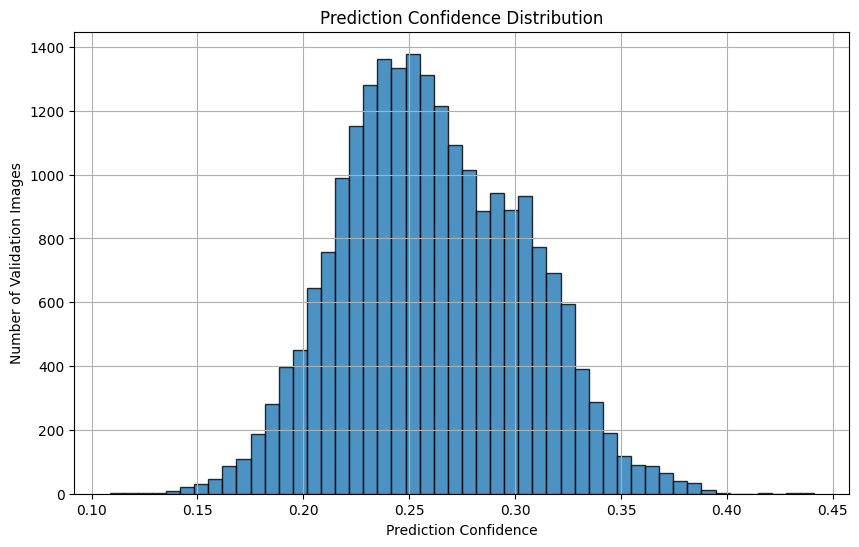

In [47]:
# ============================================================
# Cell 46 : Prediction Confidence Distribution
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    prediction_confidence.numpy(),
    bins=50,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Validation Images")
plt.title("Prediction Confidence Distribution")

plt.grid(True)

plt.show()